In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
rfm = pd.read_csv("rfm_table.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12347.0,7,1,711.79
1,12370.0,1,1,1590.82
2,12386.0,7,1,258.90
3,12395.0,11,1,346.10
4,12427.0,12,1,303.50


In [ ]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,705.000000,705.000000,705.000000,705.000000
mean,15539.954610,7.307801,1.435461,583.814879
std,1711.621792,3.984381,1.765883,1402.487738
min,12347.000000,1.000000,1.000000,11.600000
25%,14107.000000,5.000000,1.000000,182.250000
50%,15658.000000,7.000000,1.000000,311.810000
75%,17068.000000,10.000000,1.000000,523.860000
max,18269.000000,14.000000,34.000000,27834.610000


In [ ]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [ ]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1,2,3,4,5])

In [ ]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [ ]:
rfm[['R_score','F_score','M_score']] = rfm[['R_score','F_score','M_score']].astype(int)

In [ ]:
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

In [ ]:
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [ ]:
rfm.sort_values('RFM_score', ascending=False).head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
427,16210.0,2,3,5277.74,5,5,5,15,555
490,16779.0,3,2,687.83,5,5,5,15,555
395,15983.0,1,3,1148.27,5,5,5,15,555
34,12748.0,1,26,3656.04,5,5,5,15,555
314,15311.0,1,5,1905.01,5,5,5,15,555


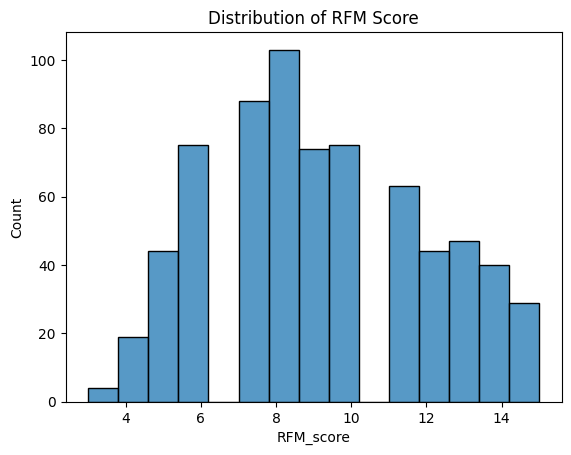

In [ ]:
sns.histplot(rfm['RFM_score'], bins=15)
plt.title("Distribution of RFM Score")
plt.show()

In [ ]:
rfm[['Recency','Frequency','Monetary']].mean()

,0
Recency,7.307801
Frequency,1.435461
Monetary,583.814879


In [ ]:
rfm.to_csv("rfm_scored_table.csv", index=False)